In [2]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt


In [3]:
#Loading Apple data between 2020 and 2026
aapl = yf.Ticker("aapl")

from datetime import datetime

today = datetime.today()

aapl_hist = aapl.history(start ="2020-01-01", end = today, interval = "1d")
print(type(aapl_hist))

<class 'pandas.DataFrame'>


In [4]:
#Writing the data into a file
import os
os.makedirs("C:/Users/muura/Desktop", exist_ok=True)
aapl_hist.to_csv("C:/Users/muura/Desktop/AAPL 2020-")

In [5]:
#Accessing the data
print(aapl_hist.iloc[1]["Close"])

71.63064575195312


In [6]:
#Building a 10 day moving average manually, use the next one always unless you are using something else than a pandas dataframe
    # list_xsmas = []
    # for i in len(aapl_hist):

    #     ten_day_closes = np.array([])
    #     data = []
    #     for i in range(10):
    #         data.append(aapl_hist.iloc[i]["Close"])
    #     ten_day_closes = np.array(data)

    #     #calculating the sma
    #     x_sma = ten_day_closes.mean()
    #     list_xsmas.append(x_sma)

    #Moving the date forward by one



In [7]:
#A way better way to do it

#Making use fo the pandas' built in rollintg window function and adding it to the apple data.
#Really useful as it automatically replaces NAN to the first 10 data points as the mean calculation can't be done.

aapl_hist["SMA100"] = (aapl_hist["Close"].rolling(100).mean())
print(aapl_hist["SMA100"])

aapl_hist["SMA50"] = (aapl_hist["Close"].rolling(50).mean())
print(aapl_hist["SMA50"])


Date
2020-01-02 00:00:00-05:00           NaN
2020-01-03 00:00:00-05:00           NaN
2020-01-06 00:00:00-05:00           NaN
2020-01-07 00:00:00-05:00           NaN
2020-01-08 00:00:00-05:00           NaN
                                ...    
2026-05-13 00:00:00-04:00    264.528318
2026-05-14 00:00:00-04:00    264.793565
2026-05-15 00:00:00-04:00    265.064240
2026-05-18 00:00:00-04:00    265.337965
2026-05-19 00:00:00-04:00    265.609116
Name: SMA100, Length: 1603, dtype: float64
Date
2020-01-02 00:00:00-05:00           NaN
2020-01-03 00:00:00-05:00           NaN
2020-01-06 00:00:00-05:00           NaN
2020-01-07 00:00:00-05:00           NaN
2020-01-08 00:00:00-05:00           NaN
                                ...    
2026-05-13 00:00:00-04:00    264.449287
2026-05-14 00:00:00-04:00    265.167920
2026-05-15 00:00:00-04:00    265.971512
2026-05-18 00:00:00-04:00    266.783852
2026-05-19 00:00:00-04:00    267.570436
Name: SMA50, Length: 1603, dtype: float64


<function matplotlib.pyplot.show(close=None, block=None)>

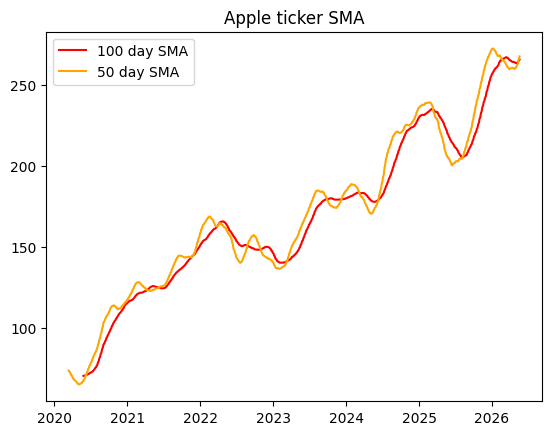

In [8]:
#Plotting the sma on a canvas

plt.plot(aapl_hist.index, aapl_hist["SMA100"], label = "100 day SMA", color = "red")
plt.plot(aapl_hist.index, aapl_hist["SMA50"], label = "50 day SMA", color = "orange")
plt.legend()
plt.title("Apple ticker SMA")

plt.show

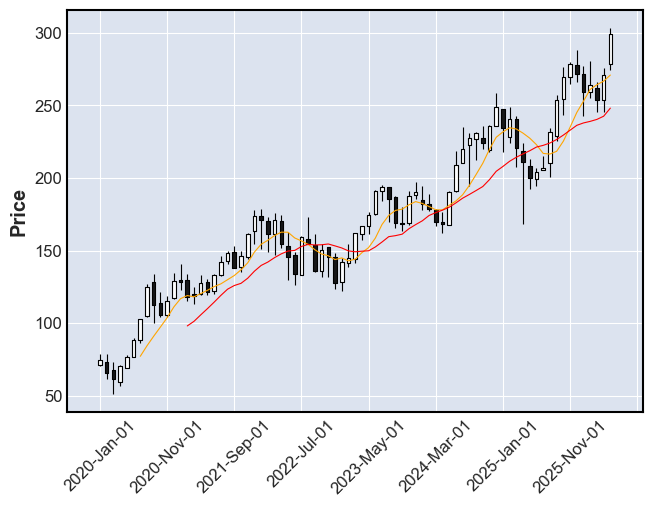

In [9]:
# Making weekly candles and weekly sma's

#Weekly candle's

import mplfinance as mpf

monthly_aapl = aapl_hist.resample("MS").agg({
        "Open": "first",
        "High": "max",
        "Low": "min",
        "Close": "last"
    })

#SMA's

monthly_aapl["7Month_SMA"] = monthly_aapl["Close"].rolling(7).mean()
monthly_aapl["14Month_SMA"] = monthly_aapl["Close"].rolling(14).mean()

# plot overlay for the SMA's

apds = [
    mpf.make_addplot(monthly_aapl["7Month_SMA"], color = "orange", width = 0.8),
    mpf.make_addplot(monthly_aapl["14Month_SMA"], color = "red", width = 0.8)
]

#plotting the candles 
mpf.plot(monthly_aapl, type="candle", addplot=apds)

In [10]:
# putting together a trading algorithm with the daily and the 50 and 100 sma

Equity = 50_000
in_trade = False

aapl_hist["Equity"] = None

for index, row in aapl_hist.iterrows():

    if not in_trade:

        if row["SMA50"] > row["SMA100"]:
            entry = float(row["Close"])
            in_trade = "long"

        elif row["SMA50"] < row["SMA100"]:
            entry = float(row["Close"])
            in_trade = "short"

    else:

        if in_trade == "long":

            if row["SMA50"] < row["SMA100"]:
                out = float(row["Close"])
                Equity *= out/entry
                in_trade = False
            
        elif in_trade == "short":    

            if row["SMA50"] > row["SMA100"]:
                out = float(row["Close"])
                Equity *= entry/out
                in_trade = False
    aapl_hist.loc[index, "Equity"] = Equity

print(aapl_hist["Equity"])





Date
2020-01-02 00:00:00-05:00           50000
2020-01-03 00:00:00-05:00           50000
2020-01-06 00:00:00-05:00           50000
2020-01-07 00:00:00-05:00           50000
2020-01-08 00:00:00-05:00           50000
                                 ...     
2026-05-13 00:00:00-04:00    76737.486829
2026-05-14 00:00:00-04:00    69964.520125
2026-05-15 00:00:00-04:00    69964.520125
2026-05-18 00:00:00-04:00    69964.520125
2026-05-19 00:00:00-04:00    69964.520125
Name: Equity, Length: 1603, dtype: object


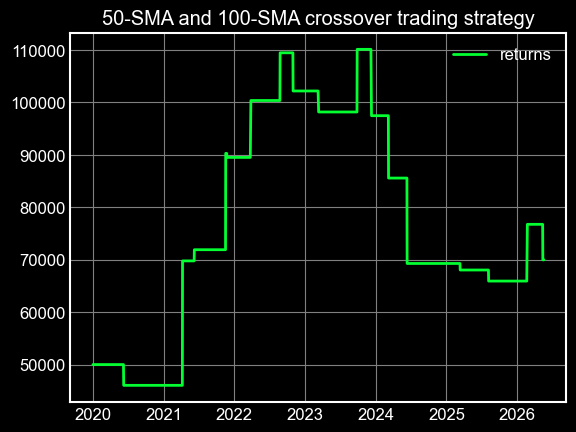

In [12]:
#Visualizing the strategy

plt.plot(aapl_hist.index, aapl_hist["Equity"], label = "returns", color = "#03ff31")
plt.style.use("dark_background")
plt.grid(color = "grey")
plt.legend()
plt.title("50-SMA and 100-SMA crossover trading strategy")
plt.show()